In [22]:
import pandas as pd
import numpy as np
import os, sys
import matplotlib.pyplot as plt


In [23]:
#rank,caption,mean,precision,votes,not_funny,somewhat_funny,funny



path = "./data/newyorker_caption_contest/data/"
dirs = os.listdir(path)
files = [os.path.join(path,i) for i in os.listdir(path) if os.path.isfile(os.path.join(path,i))]


df = pd.DataFrame()

data_frames = []
for file in files:
    
    data = pd.read_csv(file, sep=',')
    file_number_csv =  os.path.split(file)[-1]
    file_number = int(file_number_csv.replace('.csv', ''))
    data['contest_id'] = file_number #add a column with the contest id 
    # starting from 660 the rank is nolonger shown, but comparing it with https://nextml.github.io/caption-contest-data/dashboards/883.html
    # we can assume that the order is the rank 
    if file_number >= 660: 
        data.insert(0, 'rank', np.arange(0, len(data)))
    data_frames.append(data)

df = pd.concat(data_frames, ignore_index=True)
    
        

#df['contest_id'] = df['contest_id'].str.replace('.csv', '')  # Remove '.csv' from values
#df['contest_id'] = df['contest_id'].astype(int)  # Remove '.csv' from values


In [24]:
#df['rank'] = df['rank'].astype(int)

df.to_csv("./data/combined_captions.csv", index=True)
df.info()
df.head(100)
#df.tail()
df


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2292678 entries, 0 to 2292677
Data columns (total 9 columns):
 #   Column          Dtype  
---  ------          -----  
 0   rank            int64  
 1   caption         object 
 2   mean            float64
 3   precision       float64
 4   votes           int64  
 5   not_funny       int64  
 6   somewhat_funny  int64  
 7   funny           int64  
 8   contest_id      int64  
dtypes: float64(2), int64(6), object(1)
memory usage: 157.4+ MB


,rank,caption,mean,precision,votes,not_funny,somewhat_funny,funny,contest_id
0,0,I'm a congressman--obstruction is my job.,1.913043,0.094022,69,24,27,18,510
1,1,"I'm what they mean when they say, 'The middle class is getting stepped on.'",1.842105,0.191381,19,8,6,5,510
2,2,Does this suit make me look flat?,1.711111,0.112915,45,21,16,8,510
3,3,"When the right woman comes along, I'll know it.",1.625000,0.116657,32,15,14,3,510
4,4,"I used to lie in the gutter, but then I quit drinking.",1.617647,0.133610,34,19,9,6,510
...,...,...,...,...,...,...,...,...,...
2292673,4953,Looks like we took a wrong turn at the Hubble Deep Field,1.023256,0.016347,86,84,2,0,895
2292674,4954,Post-modern just doesn't do it for me.,1.022222,0.015625,90,88,2,0,895
2292675,4955,"How was I supposed to know they covered themselves up. Let's find Macy's. I suddenly feel so naked!""",1.020833,0.014654,96,94,2,0,895
2292676,4956,"No, they wanted us to teleport the giveaway car in over by the Macy’s.",1.020619,0.020619,97,96,0,1,895


In [25]:
# get rid of empty captions
# get rid of broken captions 

# find not complete parts   e.g 63867

df_cleaned = df[df['caption'].notnull()] 
df_cleaned = df_cleaned[~df_cleaned['caption'].str.contains(r'[\r\n]', regex=True)]

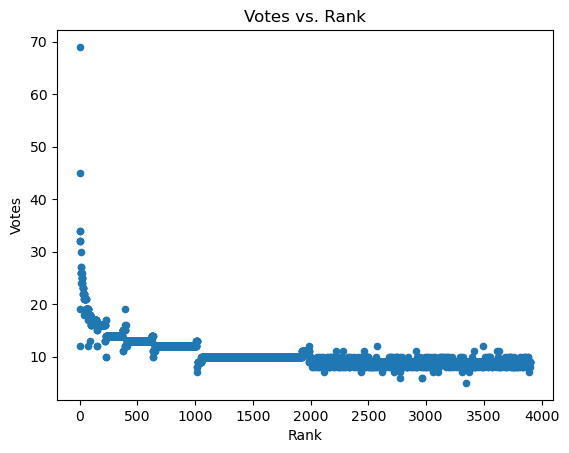

In [26]:
# Assuming 'df' is your DataFrame
df_filtered = df_cleaned[df_cleaned['contest_id'] == 510]

# Creating the scatter plot
df_filtered.plot(kind='scatter', x='rank', y='votes', title='Votes vs. Rank', xlabel='Rank', ylabel='Votes')

# Show the plot
plt.show()

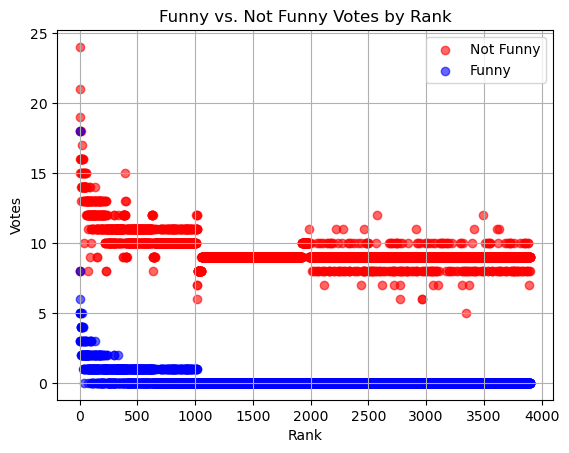

In [27]:
# Scatter plot for "not funny" votes
plt.scatter(df_filtered['rank'], df_filtered['not_funny'], color='red', label='Not Funny', alpha=0.6)

# Scatter plot for "funny" votes
plt.scatter(df_filtered['rank'], df_filtered['funny'], color='blue', label='Funny', alpha=0.6)


# Adding titles and labels
plt.title('Funny vs. Not Funny Votes by Rank')
plt.xlabel('Rank')
plt.ylabel('Votes')
plt.legend()  # Show legend
plt.grid(True)  # Optional: Adding grid for better readability
plt.show()

c:\Users\idont\anaconda3\envs\ada\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


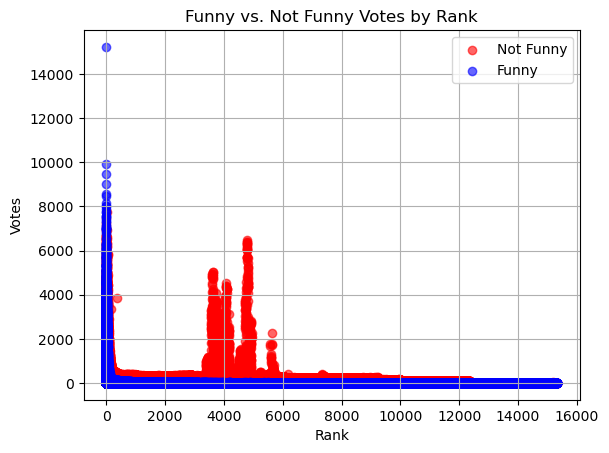

<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   rank            0 non-null      int64  
 1   caption         0 non-null      object 
 2   mean            0 non-null      float64
 3   precision       0 non-null      float64
 4   votes           0 non-null      int64  
 5   not_funny       0 non-null      int64  
 6   somewhat_funny  0 non-null      int64  
 7   funny           0 non-null      int64  
 8   contest_id      0 non-null      int64  
dtypes: float64(2), int64(6), object(1)
memory usage: 0.0+ bytes


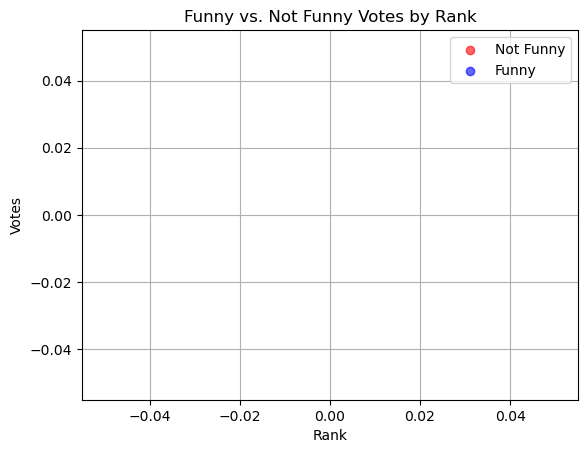

In [28]:

df_with_rank = df_cleaned[df_cleaned['rank'].notnull()]

# Scatter plot for "not funny" votes
plt.scatter(df_with_rank['rank'], df_with_rank['not_funny'], color='red', label='Not Funny', alpha=0.6)

# Scatter plot for "funny" votes
plt.scatter(df_with_rank['rank'], df_with_rank['funny'], color='blue', label='Funny', alpha=0.6)

# Adding titles and labels
plt.title('Funny vs. Not Funny Votes by Rank')
plt.xlabel('Rank')
plt.ylabel('Votes')
plt.legend()  # Show legend
plt.grid(True)  # Optional: Adding grid for better readability
plt.show()

df_without_rank = df[df['rank'].isnull()]
# index is rank
df_without_rank['rank'] = np.arange(0, len(df_without_rank))
df_without_rank.info()


# Scatter plot for "not funny" votes
plt.scatter(df_without_rank['rank'], df_without_rank['not_funny'], color='red', label='Not Funny', alpha=0.6)

# Scatter plot for "funny" votes
plt.scatter(df_without_rank['rank'], df_without_rank['funny'], color='blue', label='Funny', alpha=0.6)

# Adding titles and labels
plt.title('Funny vs. Not Funny Votes by Rank')
plt.xlabel('Rank')
plt.ylabel('Votes')
plt.legend()  # Show legend
plt.grid(True)  # Optional: Adding grid for better readability
#plt.show()


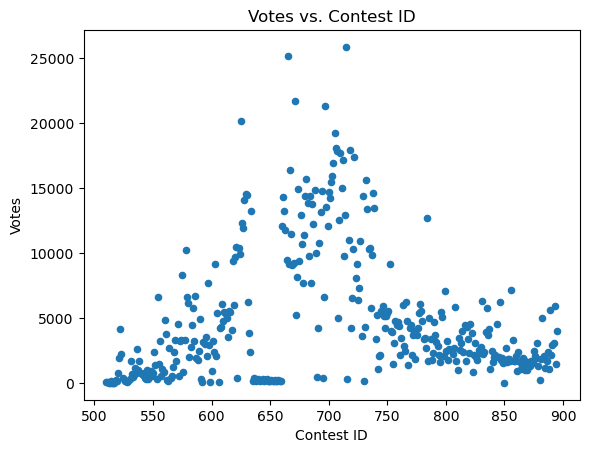

In [29]:
# Creating the scatter plot

df_max = df_cleaned[df_cleaned['rank'] == 0]


df_max.plot(kind='scatter', x='contest_id', y='votes', title='Votes vs. Contest ID', xlabel='Contest ID', ylabel='Votes')

# Show the plot
plt.show()

In [30]:
df_cleaned.describe()

,rank,mean,precision,votes,not_funny,somewhat_funny,funny,contest_id
count,2.263048e+06,2.263048e+06,2.263048e+06,2.263048e+06,2.263048e+06,2.263048e+06,2.263048e+06,2.263048e+06
mean,3.237744e+03,1.213297e+00,inf,1.271546e+02,9.196737e+01,2.500724e+01,1.017450e+01,7.058373e+02
std,2.184046e+03,1.226135e-01,NaN,3.534562e+02,1.553966e+02,1.221527e+02,9.149422e+01,1.062162e+02
min,0.000000e+00,8.571429e-01,1.546432e-04,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.100000e+02
25%,1.485000e+03,1.134021e+00,4.104463e-02,6.000000e+01,5.100000e+01,6.000000e+00,1.000000e+00,6.150000e+02
50%,2.984000e+03,1.200000e+00,4.838879e-02,8.400000e+01,6.900000e+01,1.200000e+01,2.000000e+00,7.130000e+02
75%,4.604000e+03,1.276316e+00,5.658405e-02,1.230000e+02,9.700000e+01,2.100000e+01,6.000000e+00,7.910000e+02
max,1.532800e+04,2.998918e+00,inf,2.589100e+04,7.740000e+03,9.721000e+03,1.523200e+04,8.950000e+02


In [31]:
df_cleaned[df_cleaned['rank'] == df_cleaned['rank'].max()]

,rank,caption,mean,precision,votes,not_funny,somewhat_funny,funny,contest_id
1175881,15328,"Soooo, what is it going to be tonight, a sandwich or sex?",1.0,0.133631,8,8,0,0,716


In [32]:
# Set display options for pandas
pd.set_option('display.max_colwidth', None)  # or use a specific integer to limit the width

df.iloc[[63867, 63872, 63873]]

,rank,caption,mean,precision,votes,not_funny,somewhat_funny,funny,contest_id
63867,485,I don’t think we missed out on anything not having kids.,1.388889,0.055173,126,86,31,9,523
63872,490,"So....what type of business did you say you were in?\r\n65,25,11,Well at least they're not on our backs any more.\r\n49,11,5,Planet of the Apes in 3D is a little too intense for me.\r\n49,15,4,The bonus features on this new Planet Of The Apes BluRay might be a bit too much.\r\n35,3,1,One of these monkeys must have some Shakespeare in him.\r\n51,16,4,What else do we need besides bananas?\r\n42,5,3,I told you not to vote for Trump.\r\n36,6,0,I've been hanging with you for a long time Doris and I still can't figure out what you want.\r\n37,8,1,I told you they were probably delivered in a barrel for a very good reason.\r\n51,5,4,You just had to go to Costco and get a whole barrel.\r\n44,12,3,Could it be that Nigerian email that we replied to?\r\n43,6,3,Does this mean we can't have sex?\r\n40,8,1,Anything would be more fun than this.\r\n31,3,0,WHAT CAN I SAY IT'S A MAN THING""",1.388235,0.069197,85,59,19,7,523
63873,491,They share 98% of your DNA too.,1.388235,0.073133,85,61,15,9,523


In [33]:
df[~df['caption'].isnull() == True]

,rank,caption,mean,precision,votes,not_funny,somewhat_funny,funny,contest_id
0,0,I'm a congressman--obstruction is my job.,1.913043,0.094022,69,24,27,18,510
1,1,"I'm what they mean when they say, 'The middle class is getting stepped on.'",1.842105,0.191381,19,8,6,5,510
2,2,Does this suit make me look flat?,1.711111,0.112915,45,21,16,8,510
3,3,"When the right woman comes along, I'll know it.",1.625000,0.116657,32,15,14,3,510
4,4,"I used to lie in the gutter, but then I quit drinking.",1.617647,0.133610,34,19,9,6,510
...,...,...,...,...,...,...,...,...,...
2292673,4953,Looks like we took a wrong turn at the Hubble Deep Field,1.023256,0.016347,86,84,2,0,895
2292674,4954,Post-modern just doesn't do it for me.,1.022222,0.015625,90,88,2,0,895
2292675,4955,"How was I supposed to know they covered themselves up. Let's find Macy's. I suddenly feel so naked!""",1.020833,0.014654,96,94,2,0,895
2292676,4956,"No, they wanted us to teleport the giveaway car in over by the Macy’s.",1.020619,0.020619,97,96,0,1,895
